## Imputation of time-series

Some of the code was found here for visualisation: https://cienciadedatos.net/documentos/py46-forecasting-time-series-missing-values

In [1]:
!nvidia-smi

Sat Apr 18 15:44:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:02:00.0 Off |                  N/A |
|  0%   27C    P8             13W /  575W |       2MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
import math
import torch
import torch.nn as nn

import argparse
import torch
import datetime
import json
import yaml
import os

import sys

sys.path.append(".")
sys.path.append("./models")

from models.gp_wrapper import GPWrapper
from utils import *

import matplotlib.pyplot as plt


In [3]:
color = '\033[1m\033[38;5;208m' 
print(f"{color}Version numpy: {np.__version__}")
print(f"{color}Version pytorch: {torch.__version__}")

Version numpy: 2.1.2
Version pytorch: 2.8.0+cu128


### Load Data

In [4]:
from dataset_ope import get_dataloader
gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, valid_loader, test_loader, scaler, mean_scaler = get_dataloader(device=gpu, batch_size=8)

Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Training dataset len:  4279
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Valid dataset len:  20
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Test dataset len:  28


In [5]:
station_names = ["EST107PV", "EST3012", "EST5136", "EST5149", "EST5199", "EST6000", "OPE90011", "OPE90012", "OPE90013", "OPE90014", "OPE90015"]

parameter_names = ['CHL','CL','COD','CYA','DO','EC','HAP','NO3','PH','SAT','TEM','TUR', 'HTE']

# Load complementary info. Not useful rn, it's mostly polish for titles and dates...
# TODO I guess

def load_meta_data(path_list_dates = './data/ope_andra/dates_50.csv', path_sagd_parameters = './data/ope_andra/sagd_parameters_50_hte.csv'):
    dates_data = np.loadtxt(path_list_dates, dtype=str, delimiter=',')

    sagd_parameters_data = np.loadtxt(path_sagd_parameters, dtype=str, delimiter=',')


    return dates_data, sagd_parameters_data

dates_data, sagd_parameters_data = load_meta_data()

# best way to get the index at which the test data begins
test_index = test_loader.dataset.use_index[0]
test_dates = dates_data[test_index:]

In [6]:
data_dim = 75

## Model Definition and Training

In [7]:
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, Matern

gp_kernel = (
    Matern(length_scale=10.0, nu=1.5) *
    ExpSineSquared(length_scale=2.0, periodicity=6.0)
    + Matern(length_scale=3.0, nu=1.5)
    + WhiteKernel(noise_level=0.1)
)

model = GPWrapper(gp_kernel)

In [8]:
import numpy as np
import torch
from sklearn.gaussian_process import GaussianProcessRegressor

def run_gp_and_compute_quantiles(
        X, 
        observations, 
        mask, 
        kernel,
        nsamples=100,
        qlist=[0.05,0.25,0.5,0.75,0.95],
):
    """
    Returns:
        quantiles_gp: list of quantile arrays like CSDI
            quantiles_gp[q].shape = (B, L, K)
        gp_samples: full sample tensor like CSDI (B, nsample, L, K)
    """

    B, L, K = observations.shape  # Batch, Length, Features
    mask_np = mask.cpu().numpy()
    obs_np  = observations.cpu().numpy()

    # Output containers
    gp_samples = np.zeros((B, nsamples, L, K))
    
    # Loop over batch + features
    for b in range(B):
        for k in range(K):

            # Training indices = where mask == 1
            train_idx = np.where(mask_np[b, :, k] == 1)[0]

            if len(train_idx) == 0:
                # No data → flat zero predictions
                gp_samples[b, :, :, k] = 0.0
                continue

            X_train = X[train_idx]
            y_train = obs_np[b, train_idx, k]

            gp = GaussianProcessRegressor(
                kernel=kernel,
                n_restarts_optimizer=5,
                normalize_y=True,
            )

            # Fit
            gp.fit(X_train.reshape(-1, 1), y_train)

            mean_pred, std_pred = gp.predict(X.reshape(-1, 1), return_std=True)

            samples = np.random.normal(
                loc=mean_pred[None, :],
                scale=std_pred[None, :],
                size=(nsamples, L)
            )

            # Store
            gp_samples[b, :, :, k] = samples

    # Convert to torch for quantiles
    gp_samples_torch = torch.tensor(gp_samples)   # (B, nsample, L, K)
    mask_torch = torch.tensor(mask_np).float()
    target_torch = torch.tensor(obs_np).float()

    # ----------- Compute quantiles like CSDI ----------- #
    quantiles_gp = []
    for q in qlist:
        q_val = torch.quantile(gp_samples_torch, q, dim=1)  # (B, L, K)
        # replace GP outputs with ground truth for given points
        q_val = q_val * (1 - mask_torch) + target_torch * mask_torch
        quantiles_gp.append(q_val)

    return quantiles_gp, gp_samples_torch


In [9]:
import numpy as np
from collections import defaultdict

horizons = [6, 12, 18]
n_trials = 5

results = {h: defaultdict(list) for h in horizons}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for h in horizons:
        out = evaluate_forecasting(
            model,
            test_loader,
            prediction_horizon=h,
            nsample=100,
        )
        
        for key, value in out.items():
            results[h][key].append(value)

# Compute mean & std
print("\n=== Forecasting Results ===")
for h in horizons:
    print(f"\nHorizon: {h}")
    
    for metric in results[h]:
        values = np.array(results[h][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

Trial 1/5


100%|██████████| 4/4 [01:12<00:00, 18.04s/it, rmse_total=0.572, mae_total=0.202, smape_total=30.3, batch_no=4]


Trial 2/5


100%|██████████| 4/4 [01:11<00:00, 17.85s/it, rmse_total=0.566, mae_total=0.202, smape_total=30.5, batch_no=4]


Trial 3/5


...

Trial 4/5


100%|██████████| 4/4 [01:11<00:00, 17.85s/it, rmse_total=0.562, mae_total=0.201, smape_total=30.3, batch_no=4]


Trial 5/5


100%|██████████| 4/4 [01:11<00:00, 17.87s/it, rmse_total=0.562, mae_total=0.202, smape_total=30.4, batch_no=4]



=== Forecasting Results ===

Horizon: 6
rmse: 0.4059 ± 0.0072
mae: 0.1126 ± 0.0015
smape: 20.2815 ± 0.1756
CRPS: 0.1059 ± 0.0007
CRPS_sum: 0.0617 ± 0.0002

Horizon: 12
rmse: 0.4870 ± 0.0090
mae: 0.1618 ± 0.0007
smape: 26.4087 ± 0.0674
CRPS: 0.1540 ± 0.0009
CRPS_sum: 0.1011 ± 0.0005

Horizon: 18
rmse: 0.5640 ± 0.0046
mae: 0.2010 ± 0.0009
smape: 30.3275 ± 0.0780
CRPS: 0.1968 ± 0.0008
CRPS_sum: 0.1603 ± 0.0005


In [10]:
rng = np.random.RandomState(1)

# generate one batch
for batch in test_loader:
    observed_mask = batch['observed_mask']
    # set later half to 0
    #print(observed_mask_forecast.shape)
    real_data = batch['observed_data']

    observed_mask_forecast = observed_mask.clone()
    observed_mask_forecast[:, 18:] = 0

    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_forecast

In [11]:
X = np.arange(real_data.shape[0]).reshape(-1, 1)

all_target_np = real_data
all_evalpoint_np = observed_mask.cpu() - observed_mask_forecast.cpu() #observed_mask_forecast.cpu() # with later points se tto 0
all_observed_np = observed_mask.cpu() # all points
all_given_np = observed_mask_forecast.cpu() # observations

K = real_data.shape[-1] #feature
L = real_data.shape[-2] #time length

In [12]:
quantiles_gp, gp_samples = run_gp_and_compute_quantiles(
    X=np.arange(L),
    observations=all_target_np,
    mask=all_given_np,
    kernel=gp_kernel,
    nsamples=100
)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:450: Converg

In [13]:
quantiles_gp[0].shape

torch.Size([4, 24, 75])

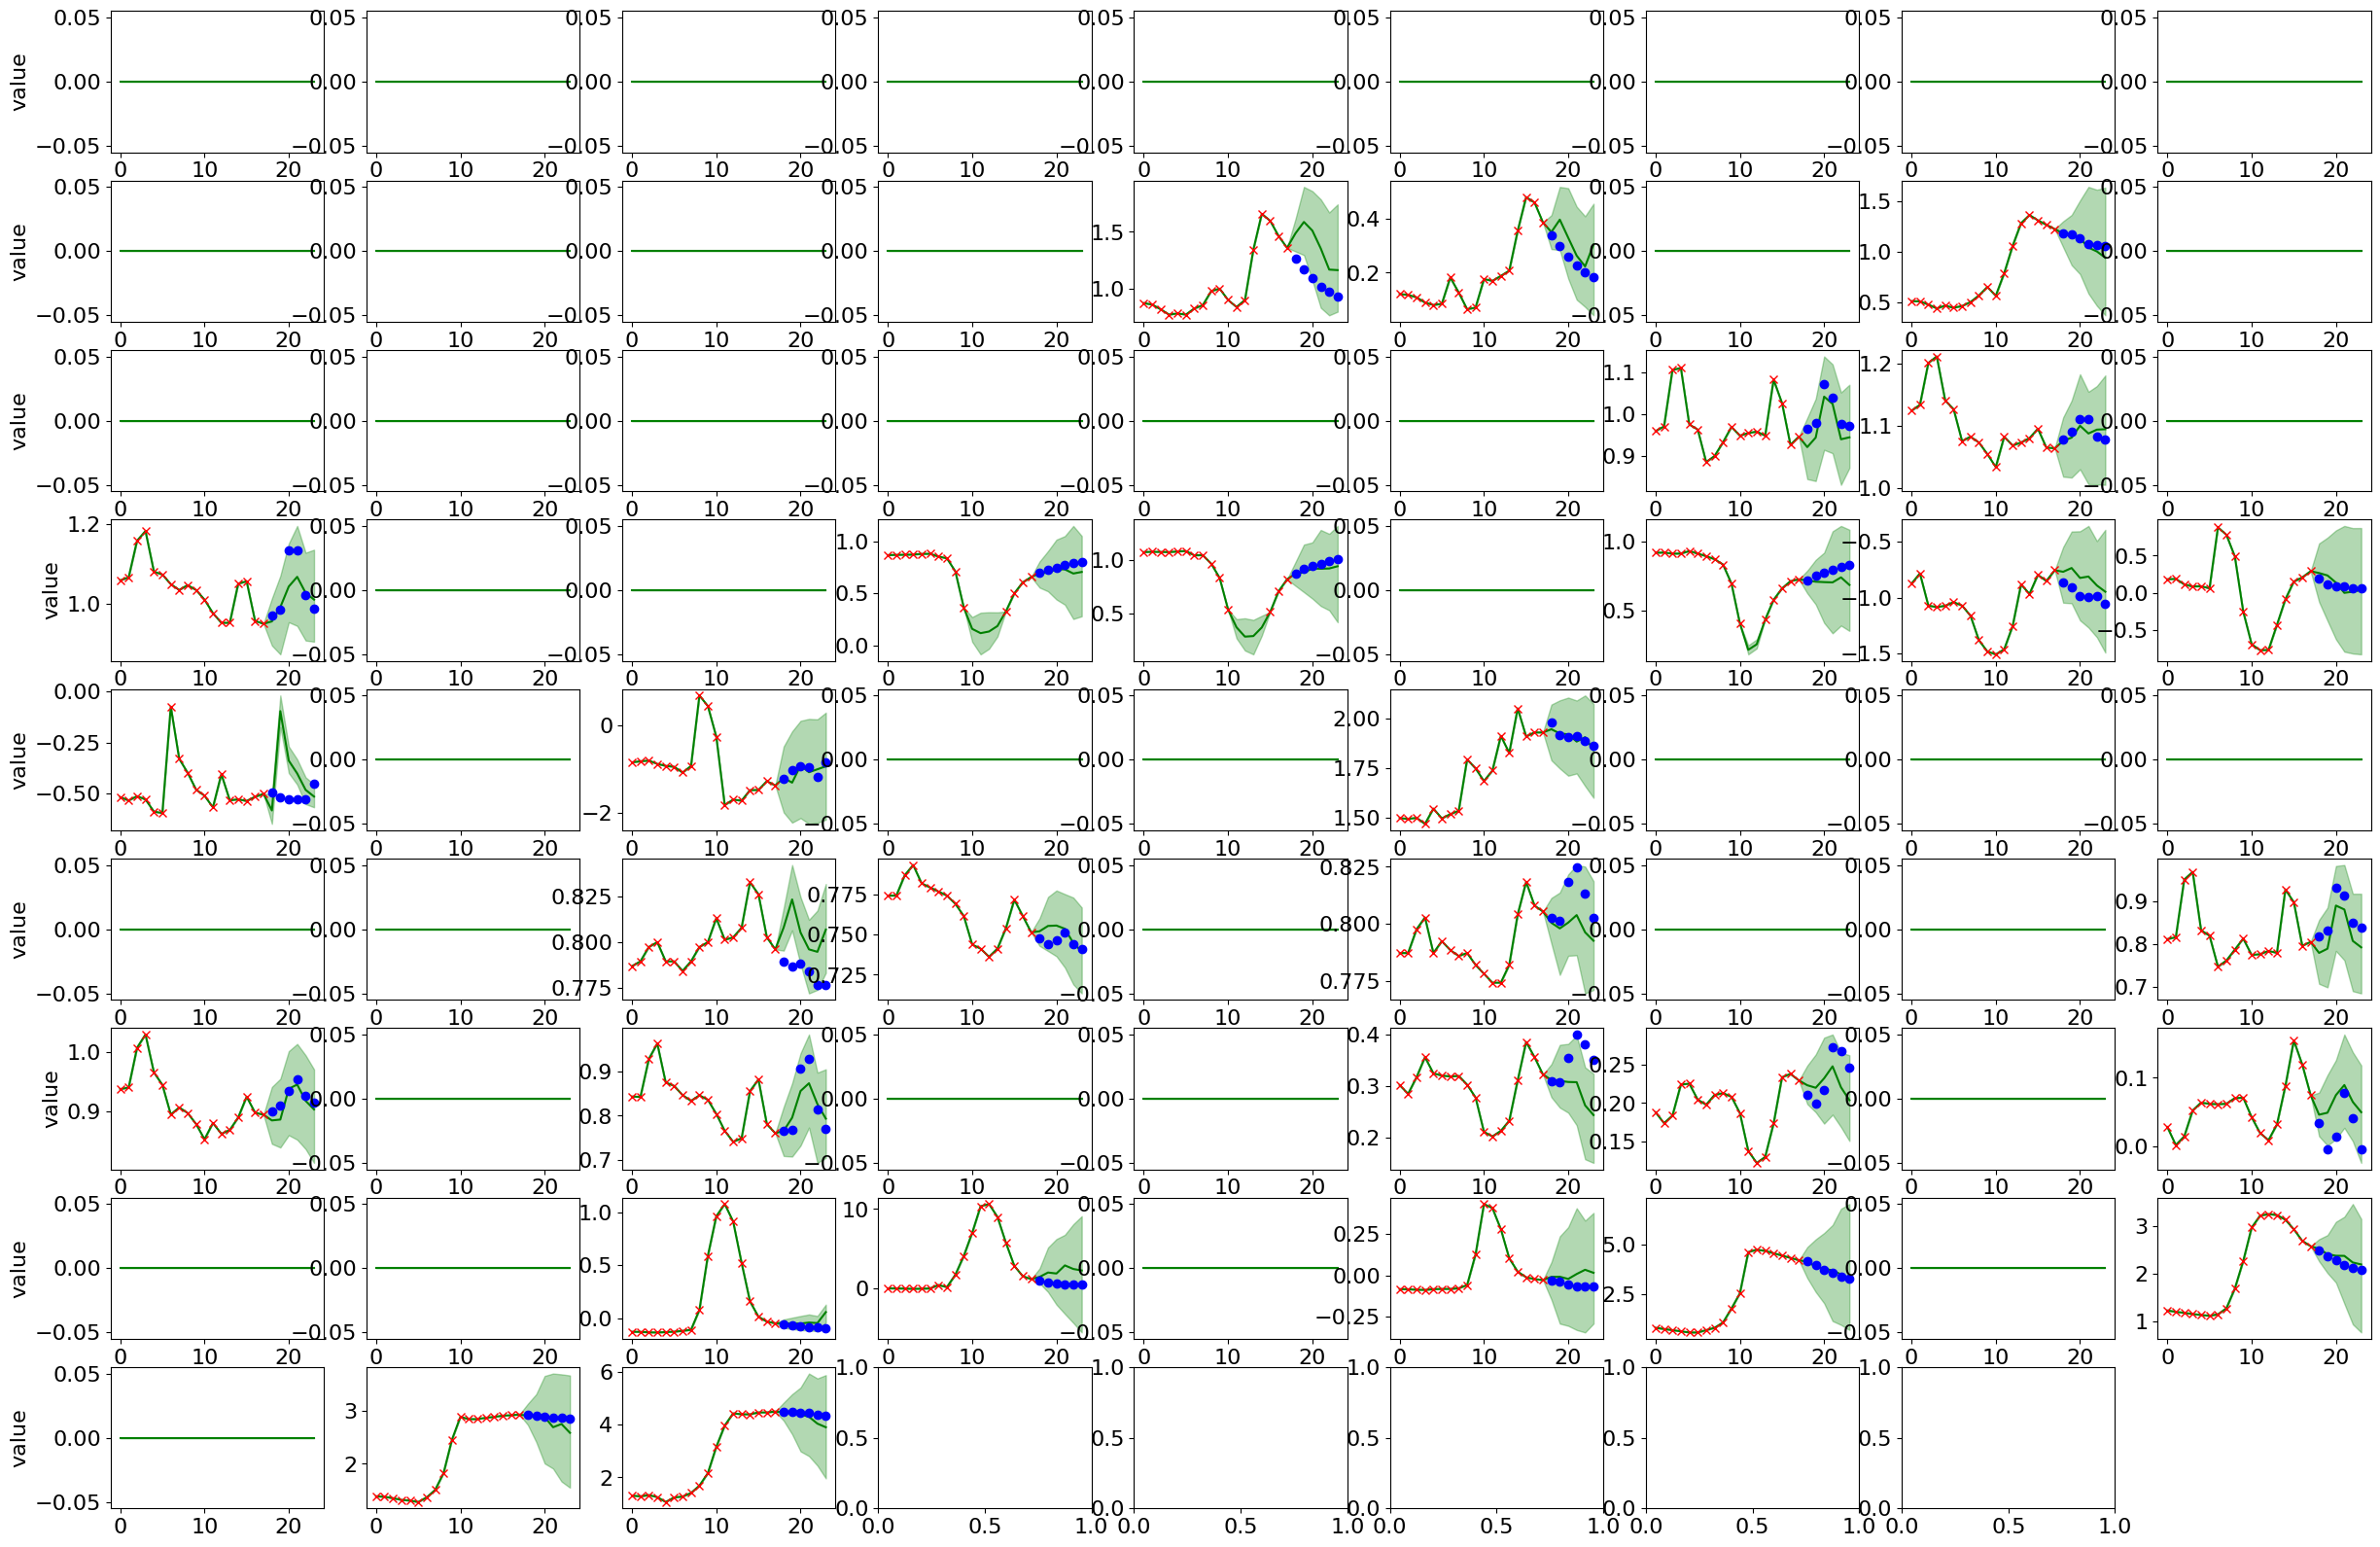

In [14]:
###airquality###
dataind = 0 #change to visualize a different sample

plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(nrows=9, ncols=9,figsize=(30.0, 20.0))
fig.delaxes(axes[-1][-1])

for k in range(K):
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    row = k // 9
    col = k % 9
    axes[row][col].plot(range(0,L), quantiles_gp[2][dataind,:,k], color = 'g',linestyle='solid',label='CSDI')
    axes[row][col].fill_between(range(0,L), quantiles_gp[0][dataind,:,k],quantiles_gp[4][dataind,:,k],
                    color='g', alpha=0.3)
    axes[row][col].plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
    axes[row][col].plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
    if col == 0:
        plt.setp(axes[row, 0], ylabel='value')
    if row == -1:
        plt.setp(axes[-1, col], xlabel='time')


In [15]:
import numpy as np
from collections import defaultdict

ratios = [0.25, 0.50, 0.75, 0.90]
n_trials = 5

results = {r: defaultdict(list) for r in ratios}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for seed, r in enumerate(ratios):
        out = evaluate_imputation(
            model,
            test_loader,
            ratio_missing=r,
            nsample=100,
            seed=seed,
        )
        
        for key, value in out.items():
            results[r][key].append(value)

# Compute mean & std
print("\n=== Imputation Results ===")
for r in ratios:
    print(f"\nMissing Ratio: {r}")
    
    for metric in results[r]:
        values = np.array(results[r][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

Trial 1/5


100%|██████████| 4/4 [00:39<00:00,  9.90s/it, rmse_total=0.526, mae_total=0.16, smape_total=26.2, batch_no=4] 


Trial 2/5


100%|██████████| 4/4 [00:40<00:00, 10.06s/it, rmse_total=0.524, mae_total=0.16, smape_total=26.2, batch_no=4] 


Trial 3/5


...

Trial 4/5


100%|██████████| 4/4 [00:38<00:00,  9.66s/it, rmse_total=0.527, mae_total=0.16, smape_total=26.2, batch_no=4] 


Trial 5/5


100%|██████████| 4/4 [00:40<00:00, 10.03s/it, rmse_total=0.527, mae_total=0.16, smape_total=26.3, batch_no=4] 



=== Imputation Results ===

Missing Ratio: 0.25
rmse: 0.1609 ± 0.0008
mae: 0.0457 ± 0.0002
smape: 9.9667 ± 0.0560
CRPS: 0.0438 ± 0.0001
CRPS_sum: 0.0419 ± 0.0001

Missing Ratio: 0.5
rmse: 0.1915 ± 0.0004
mae: 0.0638 ± 0.0003
smape: 13.7339 ± 0.0531
CRPS: 0.0602 ± 0.0002
CRPS_sum: 0.0563 ± 0.0001

Missing Ratio: 0.75
rmse: 0.3839 ± 0.0059
mae: 0.1044 ± 0.0009
smape: 18.9232 ± 0.0734
CRPS: 0.1010 ± 0.0006
CRPS_sum: 0.0816 ± 0.0004

Missing Ratio: 0.9
rmse: 0.5257 ± 0.0012
mae: 0.1596 ± 0.0004
smape: 26.2071 ± 0.0546
CRPS: 0.1563 ± 0.0003
CRPS_sum: 0.1151 ± 0.0003


In [16]:
# generate one batch
for batch in test_loader:
    observed_mask = batch['observed_mask']

    real_data = batch['observed_data']
    
    ratio_to_keep = 1. - 0.55 # 55% missing
    timesteps_to_keep = int(ratio_to_keep * observed_mask.shape[1])
    observed_mask_imputation = torch.zeros_like(observed_mask)
    for i in range(observed_mask.shape[-1]):
        rng = np.random.RandomState(i)
        observation_indices = sorted(rng.choice(np.arange(observed_mask.shape[1]), size=timesteps_to_keep, replace=False))
        observed_mask_imputation[:, observation_indices, i] = observed_mask[:, observation_indices, i]

    #print(observed_mask_imputation[0])

    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_imputation
    break

X = np.arange(real_data.shape[0]).reshape(-1, 1)

all_target_np = real_data
all_evalpoint_np = observed_mask.cpu() - observed_mask_imputation.cpu() #observed_mask_forecast.cpu() # with later points se tto 0
all_observed_np = observed_mask.cpu() # all points
all_given_np = observed_mask_imputation.cpu() # observations

K = real_data.shape[-1] #feature
L = real_data.shape[-2] #time length

In [17]:
# let's print shapes
print("all_target_np", all_target_np.shape)
print("all_evalpoint_np", all_evalpoint_np.shape)
print("all_observed_np", all_observed_np.shape)
print("all_given_np", all_given_np.shape)


all_target_np torch.Size([8, 24, 75])
all_evalpoint_np torch.Size([8, 24, 75])
all_observed_np torch.Size([8, 24, 75])
all_given_np torch.Size([8, 24, 75])


In [18]:
quantiles_gp, gp_samples = run_gp_and_compute_quantiles(
    X=np.arange(L),
    observations=all_target_np,
    mask=all_given_np,
    kernel=gp_kernel,
    nsamples=100
)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__periodicity is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:440: Converge

In [19]:
len(quantiles_gp)

5

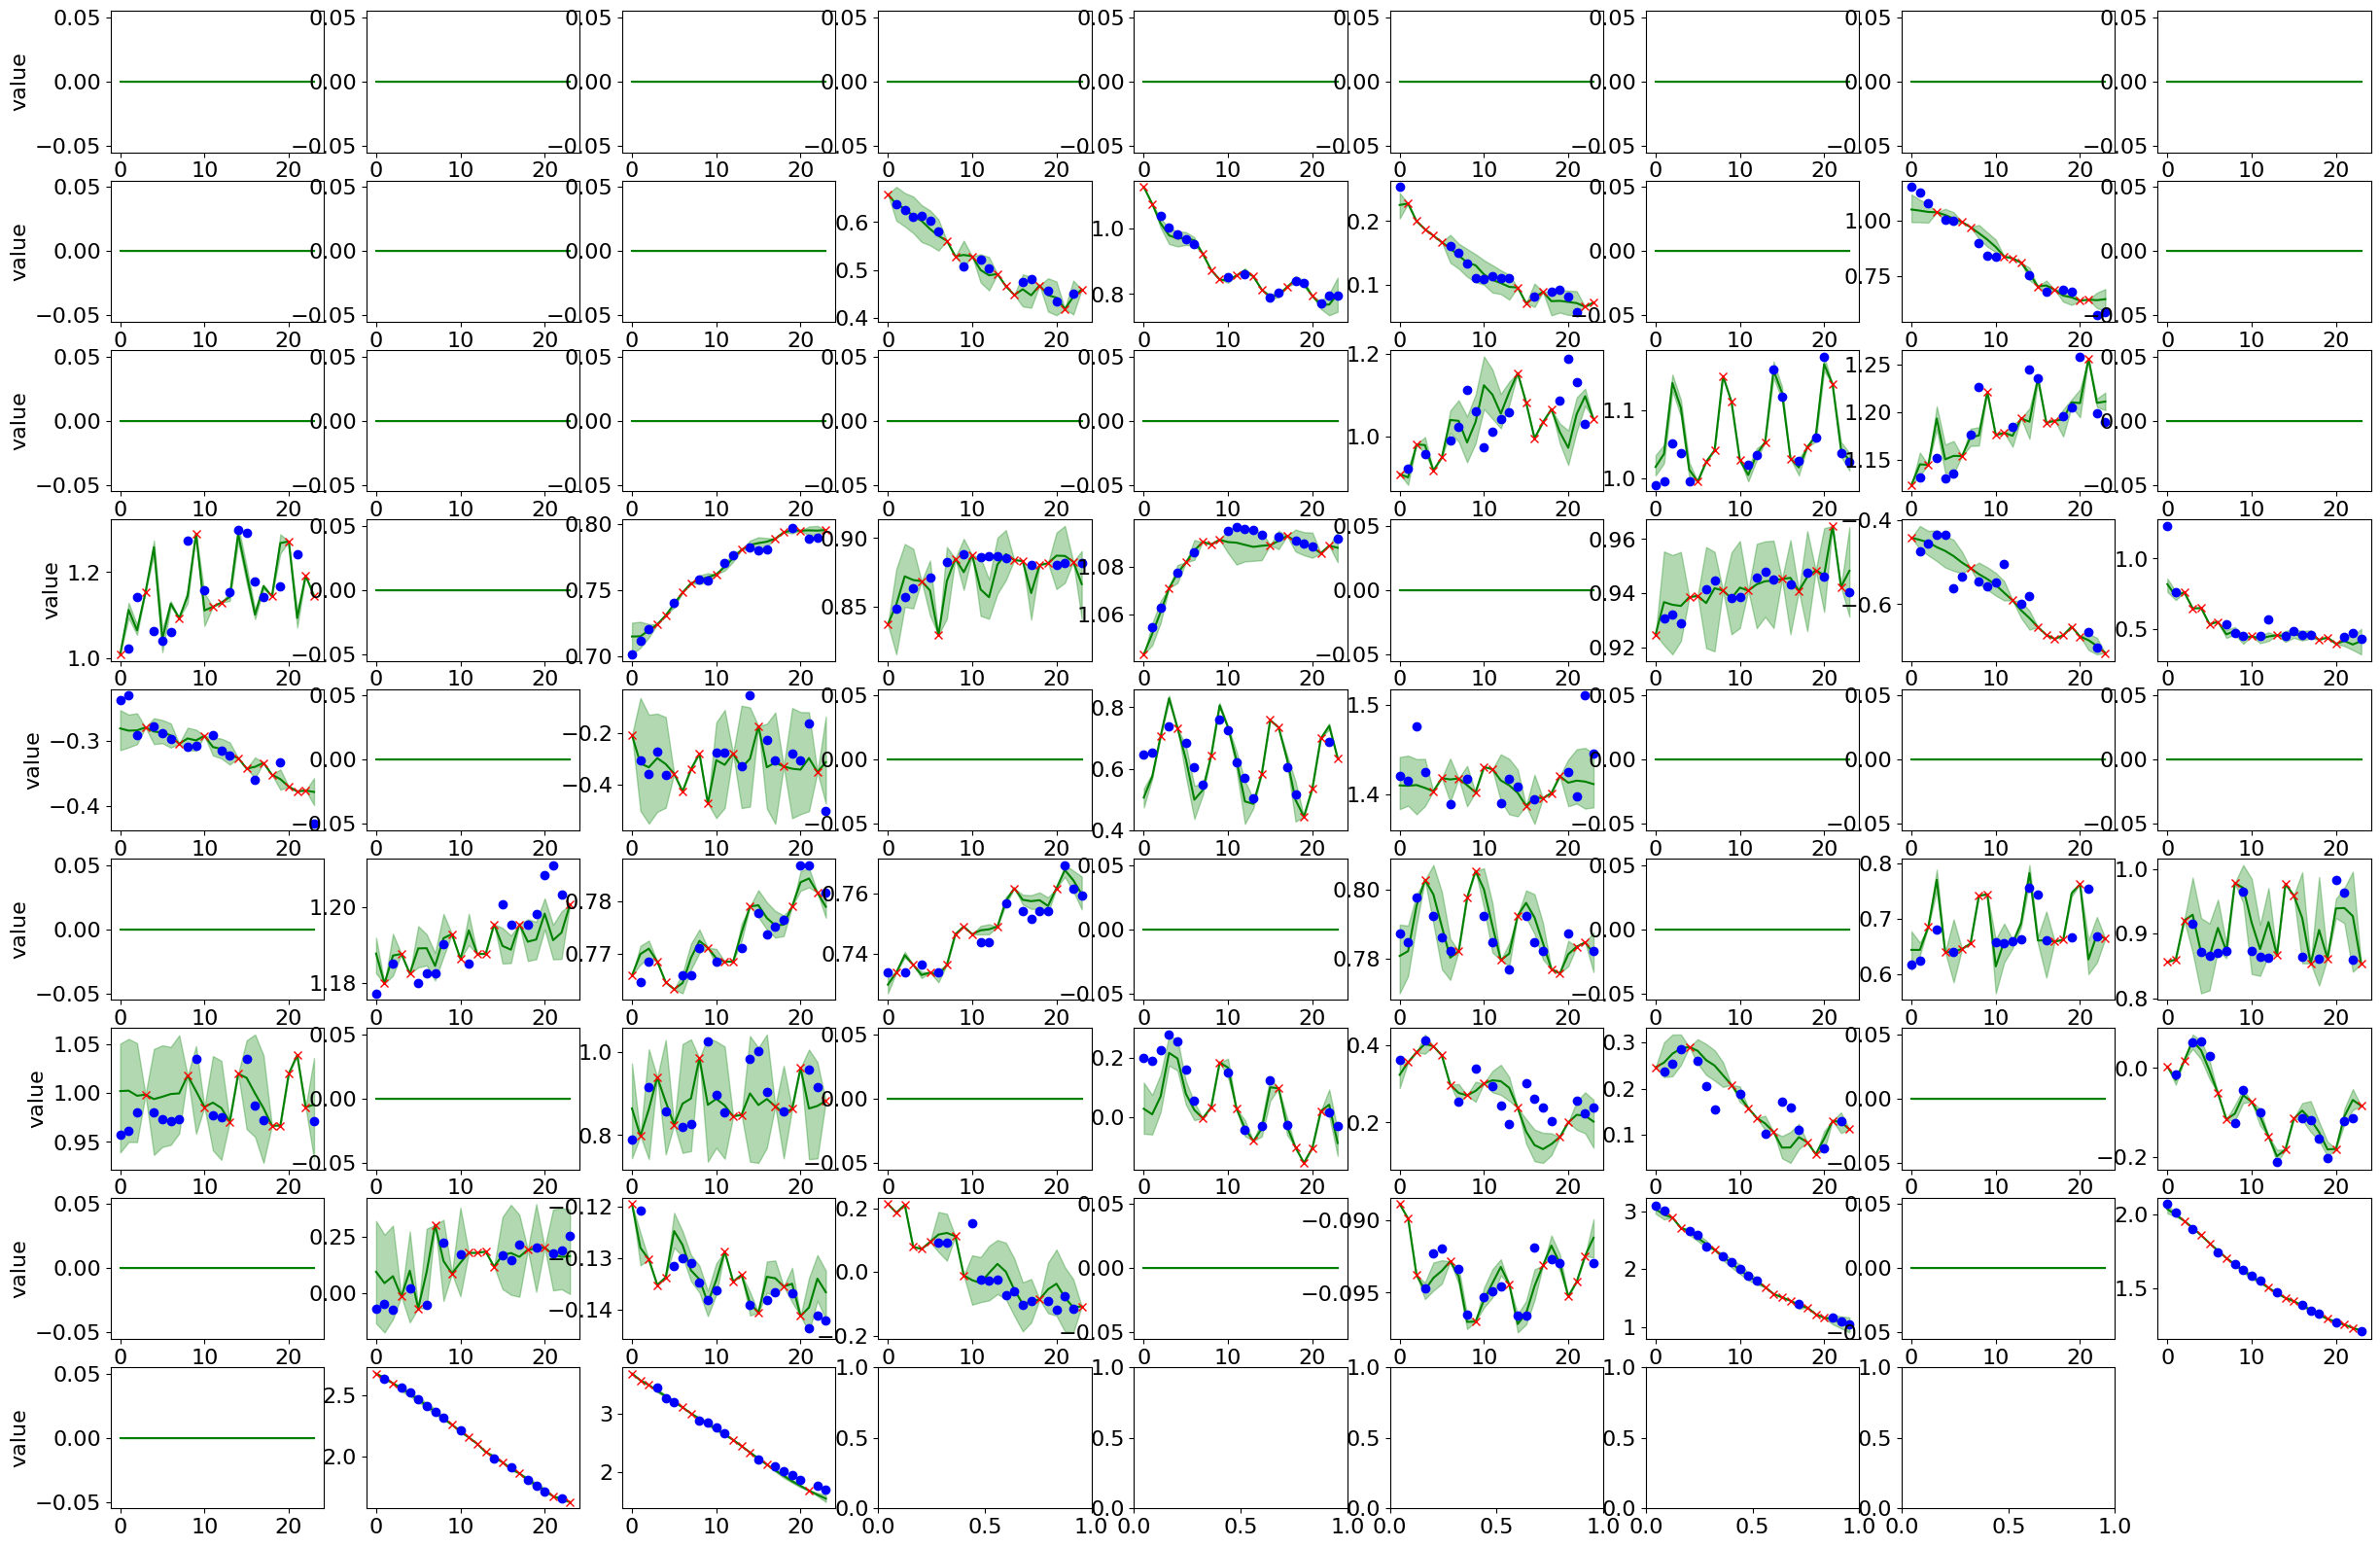

In [20]:
###airquality###
dataind = 7 #change to visualize a different sample

plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(nrows=9, ncols=9,figsize=(30.0, 20.0))
fig.delaxes(axes[-1][-1])

for k in range(K):
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    row = k // 9
    col = k % 9
    axes[row][col].plot(range(0,L), quantiles_gp[2][dataind,:,k], color = 'g',linestyle='solid',label='CSDI')
    axes[row][col].fill_between(range(0,L), quantiles_gp[0][dataind,:,k],quantiles_gp[4][dataind,:,k],
                    color='g', alpha=0.3)
    axes[row][col].plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
    axes[row][col].plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
    if col == 0:
        plt.setp(axes[row, 0], ylabel='value')
    if row == -1:
        plt.setp(axes[-1, col], xlabel='time')
# 26

[Text(0.5, 4.444444444444452, 'time')]

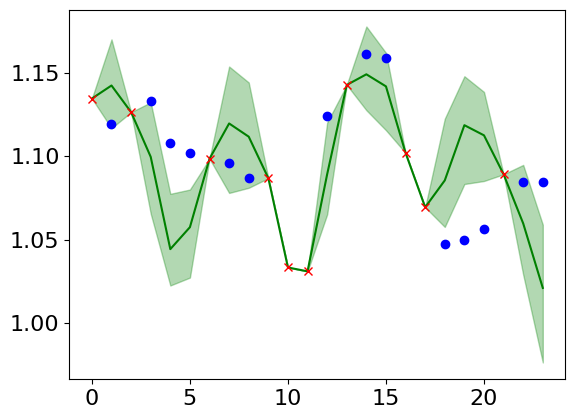

In [21]:
###airquality###
dataind = 0 #change to visualize a different sample

nb_var=25

plt.rcParams["font.size"] = 16

df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,nb_var], "y":all_evalpoint_np[dataind,:,nb_var]})
df = df[df.y != 0]
df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,nb_var], "y":all_given_np[dataind,:,nb_var]})
df2 = df2[df2.y != 0]
row = k // 9
col = k % 9
plt.plot(range(0,L), quantiles_gp[2][dataind,:,nb_var], color = 'g',linestyle='solid',label='CSDI')
plt.fill_between(range(0,L), quantiles_gp[0][dataind,:,nb_var],quantiles_gp[4][dataind,:,nb_var],
                color='g', alpha=0.3)
plt.plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
plt.plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
plt.setp(axes[row, 0], ylabel='value')
plt.setp(axes[-1, col], xlabel='time')
# 26

In [22]:
# let's print what variable is the nb 25
print("variable name:", sagd_parameters_data[nb_var])

variable name: OPE90013_DO
